![DengAI Header](../Image/flickr-mosq.jpg)

# 🦟 DengAI: Predicting Dengue Fever Cases
## A Machine Learning Approach to Forecast Disease Spread

---

**Author:** Albert Raphael Assimagbe  
**Date:** March 14, 2026  
**Deadline:** Final Submission

---

### 📋 Project Overview

Dengue fever is a mosquito-borne viral infection that poses a significant public health challenge in tropical and subtropical regions. The transmission of the dengue virus is heavily influenced by environmental factors such as temperature, precipitation, and vegetation. By analyzing these factors, we can build predictive models to forecast future outbreaks, helping public health officials allocate resources more effectively.

#### 🎯 Project Goals
1. **Exploratory Data Analysis (EDA):** Understand patterns, trends, and relationships in the data.
2. **Data Preprocessing:** Handle missing values, engineer features, and prepare data for modeling.
3. **Model Building & Comparison:** Train and compare multiple machine learning algorithms.
4. **Hyperparameter Tuning:** Optimize the best-performing model.
5. **Prediction & Submission:** Generate predictions on the test set and create a submission file.

#### 📊 Dataset Description
- Two cities: San Juan (sj) and Iquitos (iq)
- Weekly data from 1990 to 2013
- Environmental features: temperature, precipitation, humidity, vegetation indices (NDVI), etc.
- Target variable: `total_cases` (number of dengue cases per week)

---
## 1. Setup and Library Imports

In [68]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


---
## 2. Data Loading

In [69]:
# Load datasets
train_features = pd.read_csv('../Data/dengue_features_train.csv')
train_labels = pd.read_csv('../Data/dengue_labels_train.csv')
test_features = pd.read_csv('../Data/dengue_features_test.csv')

# Merge training features with labels
train_data = pd.merge(train_features, train_labels, on=['city', 'year', 'weekofyear'])

print(f"✅ Training data shape: {train_data.shape}")
print(f"✅ Test data shape: {test_features.shape}")

✅ Training data shape: (1456, 25)
✅ Test data shape: (416, 24)


In [70]:
# Display first few rows of training data
train_data.head()

,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases
0,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,...,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0,4
1,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,...,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6,5
2,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,...,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4,4
3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,...,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0,3
4,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,...,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8,6


---
## 3. Initial Data Exploration

In [71]:
# Basic information about the dataset
print("🔍 Dataset Info:")
print("=" * 50)
train_data.info()

🔍 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1456 entries, 0 to 1455
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   city                                   1456 non-null   str    
 1   year                                   1456 non-null   int64  
 2   weekofyear                             1456 non-null   int64  
 3   week_start_date                        1456 non-null   str    
 4   ndvi_ne                                1262 non-null   float64
 5   ndvi_nw                                1404 non-null   float64
 6   ndvi_se                                1434 non-null   float64
 7   ndvi_sw                                1434 non-null   float64
 8   precipitation_amt_mm                   1443 non-null   float64
 9   reanalysis_air_temp_k                  1446 non-null   float64
 10  reanalysis_avg_temp_k                  1446 non-null   float64
 11 

In [72]:
# Statistical summary
print("\n📊 Descriptive Statistics:")
print("=" * 50)
train_data.describe()


📊 Descriptive Statistics:


,year,weekofyear,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,...,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases
count,1456.000000,1456.000000,1262.000000,1404.000000,1434.000000,1434.000000,1443.000000,1446.000000,1446.000000,1446.000000,...,1446.000000,1443.000000,1446.000000,1446.000000,1413.000000,1413.000000,1436.000000,1442.000000,1434.000000,1456.000000
mean,2001.031593,26.503434,0.142294,0.130553,0.203783,0.202305,45.760388,298.701852,299.225578,295.246356,...,82.161959,45.760388,16.746427,4.903754,27.185783,8.059328,32.452437,22.102150,39.326360,24.675137
std,5.408314,15.019437,0.140531,0.119999,0.073860,0.083903,43.715537,1.362420,1.261715,1.527810,...,7.153897,43.715537,1.542494,3.546445,1.292347,2.128568,1.959318,1.574066,47.455314,43.596000
min,1990.000000,1.000000,-0.406250,-0.456100,-0.015533,-0.063457,0.000000,294.635714,294.892857,289.642857,...,57.787143,0.000000,11.715714,1.357143,21.400000,4.528571,26.700000,14.700000,0.000000,0.000000
25%,1997.000000,13.750000,0.044950,0.049217,0.155087,0.144209,9.800000,297.658929,298.257143,294.118929,...,77.177143,9.800000,15.557143,2.328571,26.300000,6.514286,31.100000,21.100000,8.700000,5.000000
50%,2002.000000,26.500000,0.128817,0.121429,0.196050,0.189450,38.340000,298.646429,299.289286,295.640714,...,80.301429,38.340000,17.087143,2.857143,27.414286,7.300000,32.800000,22.200000,23.850000,12.000000
75%,2005.000000,39.250000,0.248483,0.216600,0.248846,0.246982,70.235000,299.833571,300.207143,296.460000,...,86.357857,70.235000,17.978214,7.625000,28.157143,9.566667,33.900000,23.300000,53.900000,28.000000
max,2010.000000,53.000000,0.508357,0.454429,0.538314,0.546017,390.600000,302.200000,302.928571,298.450000,...,98.610000,390.600000,20.461429,16.028571,30.800000,15.800000,42.200000,25.600000,543.300000,461.000000


In [73]:
# Check for missing values
missing_values = train_data.isnull().sum()
missing_percentage = (missing_values / len(train_data)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage': missing_percentage
}).sort_values('Missing Count', ascending=False)

print("🔍 Missing Values Analysis:")
print("=" * 50)
missing_df[missing_df['Missing Count'] > 0]

🔍 Missing Values Analysis:


,Missing Count,Percentage
ndvi_ne,194,13.324176
ndvi_nw,52,3.571429
station_avg_temp_c,43,2.953297
station_diur_temp_rng_c,43,2.953297
ndvi_se,22,1.510989
ndvi_sw,22,1.510989
station_precip_mm,22,1.510989
station_max_temp_c,20,1.373626
station_min_temp_c,14,0.961538
precipitation_amt_mm,13,0.892857


In [74]:
# Check unique values in categorical columns
print("🏙️ Cities:", train_data['city'].unique())
print("📅 Years range:", train_data['year'].min(), "-", train_data['year'].max())
print("📆 Weeks range:", train_data['weekofyear'].min(), "-", train_data['weekofyear'].max())

🏙️ Cities: <StringArray>
['sj', 'iq']
Length: 2, dtype: str
📅 Years range: 1990 - 2010
📆 Weeks range: 1 - 53


---
## 4. Data Cleaning - Handling Missing Values

In [75]:
# Create a copy for cleaning
train_data_clean = train_data.copy()

# Apply forward fill to handle missing values (time-series appropriate)
train_data_clean.ffill(inplace=True)

# Verify no missing values remain
print(f"✅ Remaining missing values: {train_data_clean.isnull().sum().sum()}")
print(f"✅ Data shape after cleaning: {train_data_clean.shape}")

✅ Remaining missing values: 0
✅ Data shape after cleaning: (1456, 25)


---
## 5. Feature Engineering

In [76]:
# Convert week_start_date to datetime
train_data_clean['week_start_date'] = pd.to_datetime(train_data_clean['week_start_date'])

# Extract temporal features
train_data_clean['month'] = train_data_clean['week_start_date'].dt.month
train_data_clean['day_of_year'] = train_data_clean['week_start_date'].dt.dayofyear

# Create season feature (for tropical regions)
def get_season(month):
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    else:
        return 'fall'

train_data_clean['season'] = train_data_clean['month'].apply(get_season)

# One-hot encode categorical variables
train_data_clean = pd.get_dummies(train_data_clean, columns=['city', 'season'], drop_first=True)

print(f"✅ Feature engineering complete. New shape: {train_data_clean.shape}")

✅ Feature engineering complete. New shape: (1456, 30)


In [77]:
# Display updated dataframe
train_data_clean.head()

,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,...,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases,month,day_of_year,city_sj,season_spring,season_summer,season_winter
0,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,297.742857,...,29.4,20.0,16.0,4,4,120,True,True,False,False
1,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,298.442857,...,31.7,22.2,8.6,5,5,127,True,True,False,False
2,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,298.878571,...,32.2,22.8,41.4,4,5,134,True,True,False,False
3,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,299.228571,...,33.3,23.3,4.0,3,5,141,True,True,False,False
4,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,299.664286,...,35.0,23.9,5.8,6,5,148,True,True,False,False


---
## 6. Exploratory Data Analysis (EDA)

### 6.1 Target Variable Analysis

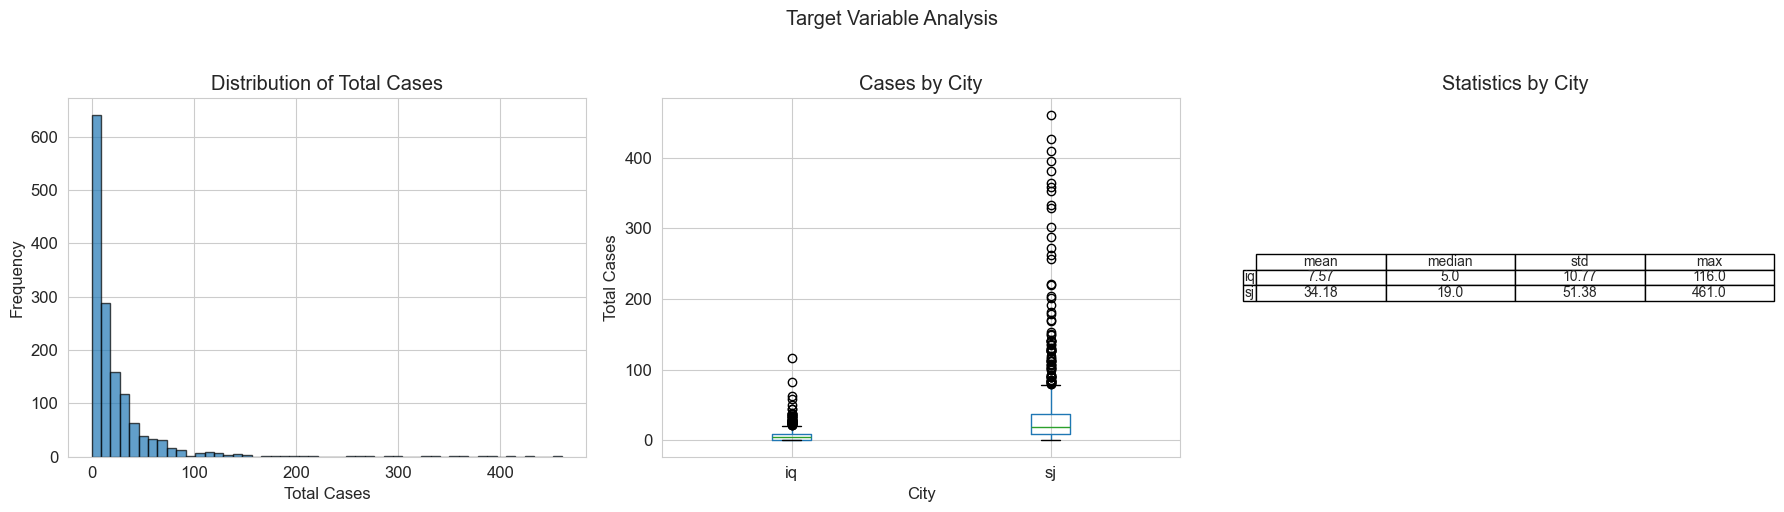

In [78]:
# Create a city column for plotting
train_data_plot = train_data_clean.copy()
city_map = {True: 'sj', False: 'iq'}
train_data_plot['city'] = train_data_plot['city_sj'].map(city_map)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution of total cases
axes[0].hist(train_data_plot['total_cases'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Total Cases')
axes[0].set_xlabel('Total Cases')
axes[0].set_ylabel('Frequency')

# Box plot by city
train_data_plot.boxplot(column='total_cases', by='city', ax=axes[1])
axes[1].set_title('Cases by City')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Total Cases')

# Statistics by city
city_stats = train_data_plot.groupby('city')['total_cases'].agg(['mean', 'median', 'std', 'max'])
axes[2].axis('tight')
axes[2].axis('off')
table = axes[2].table(cellText=city_stats.round(2).values,
                      rowLabels=city_stats.index,
                      colLabels=city_stats.columns,
                      cellLoc='center',
                      loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
axes[2].set_title('Statistics by City')

plt.suptitle('Target Variable Analysis', y=1.02)
plt.tight_layout()
plt.show()

### 6.2 Time Series Analysis

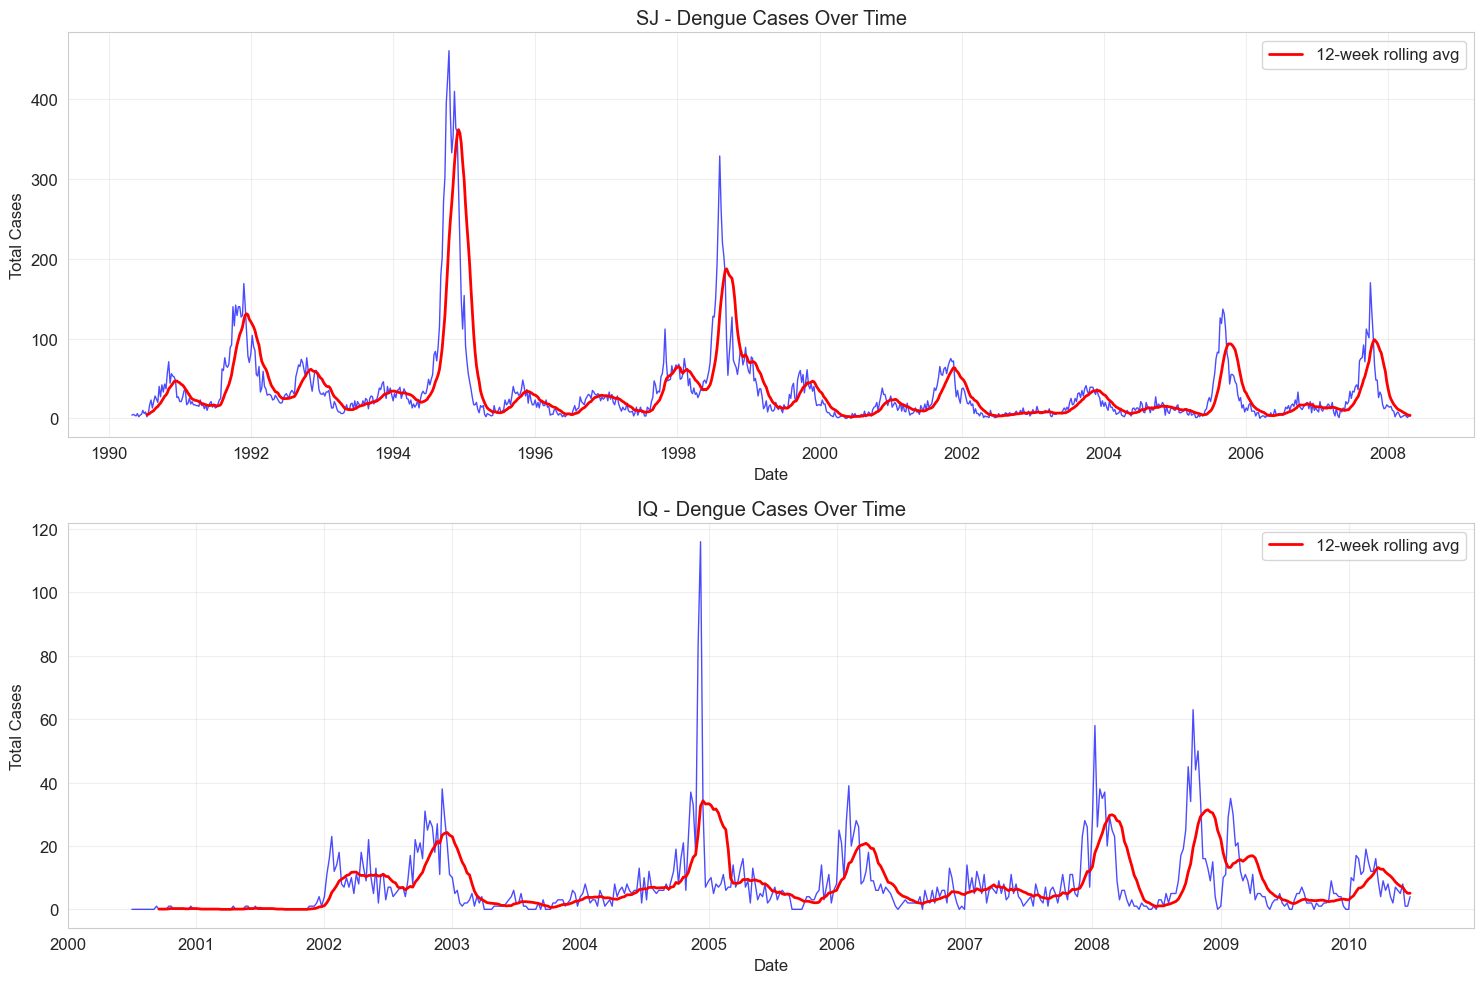

In [79]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

for idx, city in enumerate(['sj', 'iq']):
    city_data = train_data_plot[train_data_plot['city'] == city]
    axes[idx].plot(city_data['week_start_date'], city_data['total_cases'], 
                   color='blue', alpha=0.7, linewidth=1)
    axes[idx].set_title(f'{city.upper()} - Dengue Cases Over Time')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Total Cases')
    axes[idx].grid(True, alpha=0.3)
    
    # Add rolling average
    rolling_mean = city_data['total_cases'].rolling(window=12).mean()
    axes[idx].plot(city_data['week_start_date'], rolling_mean, 
                   color='red', linewidth=2, label='12-week rolling avg')
    axes[idx].legend()

plt.tight_layout()
plt.show()

### 6.3 Seasonal Patterns

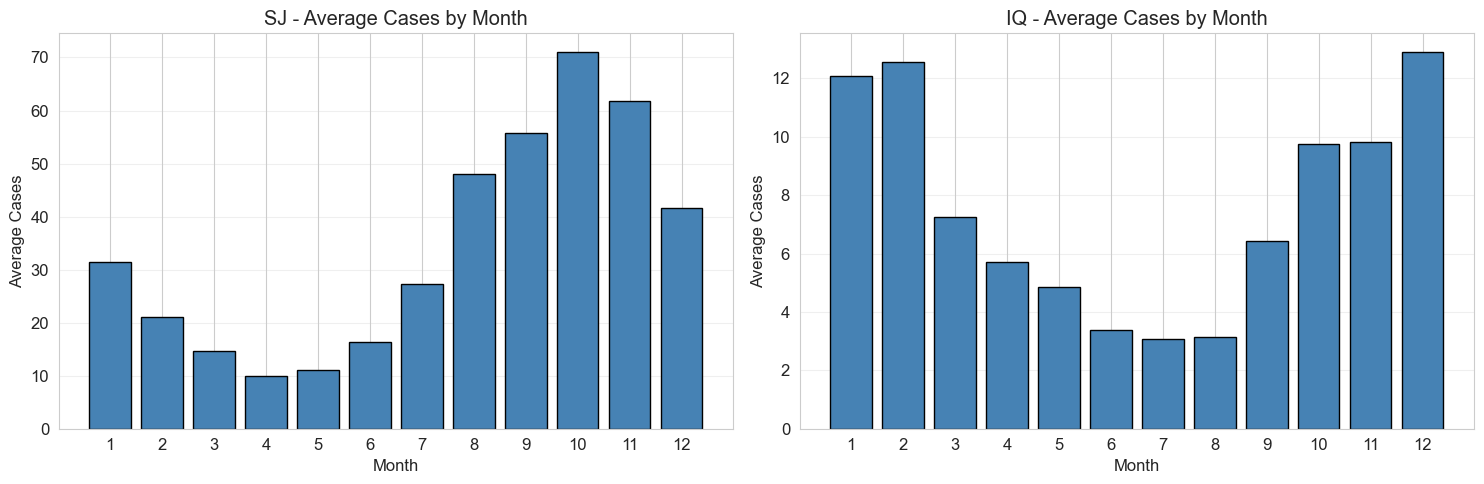

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for idx, city in enumerate(['sj', 'iq']):
    city_data = train_data_plot[train_data_plot['city'] == city]
    
    # Group by month
    monthly_avg = city_data.groupby('month')['total_cases'].mean()
    
    axes[idx].bar(monthly_avg.index, monthly_avg.values, color='steelblue', edgecolor='black')
    axes[idx].set_title(f'{city.upper()} - Average Cases by Month')
    axes[idx].set_xlabel('Month')
    axes[idx].set_ylabel('Average Cases')
    axes[idx].set_xticks(range(1, 13))
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 6.4 Correlation Analysis

In [81]:
# Select numeric columns
numeric_cols = train_data_clean.select_dtypes(include=[np.number]).columns

# Calculate correlation with target
correlation_with_target = pd.DataFrame({
    'Feature': numeric_cols,
    'Correlation': [train_data_clean[col].corr(train_data_clean['total_cases']) 
                    for col in numeric_cols]
}).sort_values('Correlation', ascending=False)

print("📊 Top 10 Features Correlated with Total Cases:")
print("=" * 50)
correlation_with_target.head(10)

📊 Top 10 Features Correlated with Total Cases:


,Feature,Correlation
22,total_cases,1.000000
11,reanalysis_min_air_temp_k,0.325335
20,station_min_temp_c,0.264715
7,reanalysis_air_temp_k,0.263487
1,weekofyear,0.216452
23,month,0.215737
24,day_of_year,0.214172
8,reanalysis_avg_temp_k,0.149274
9,reanalysis_dew_point_temp_k,0.139027
15,reanalysis_specific_humidity_g_per_kg,0.126304


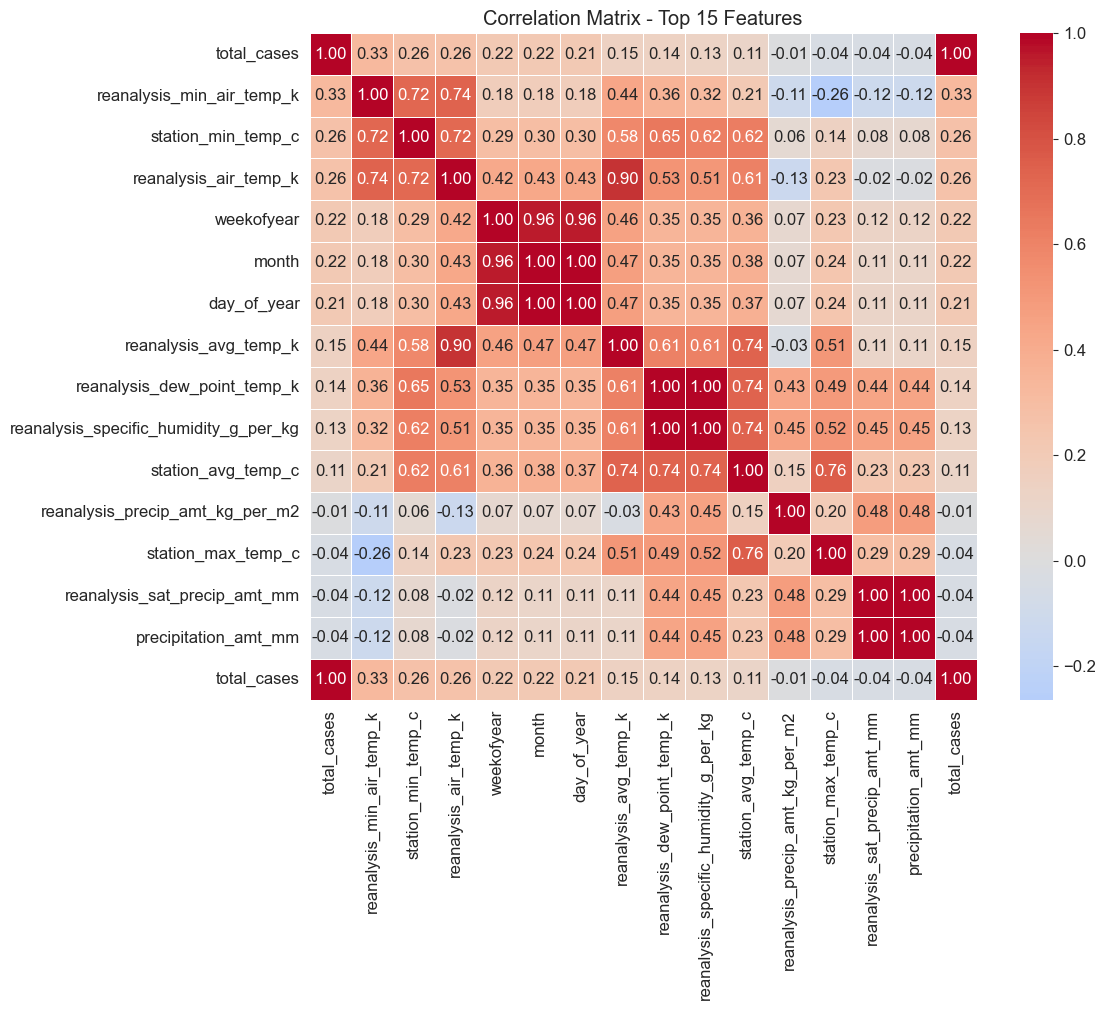

In [82]:
# Correlation heatmap (top features)
top_features = correlation_with_target.head(15)['Feature'].tolist()
top_features.append('total_cases')

plt.figure(figsize=(12, 10))
corr_matrix = train_data_clean[top_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix - Top 15 Features')
plt.tight_layout()
plt.show()

### 6.5 Feature Distributions by City

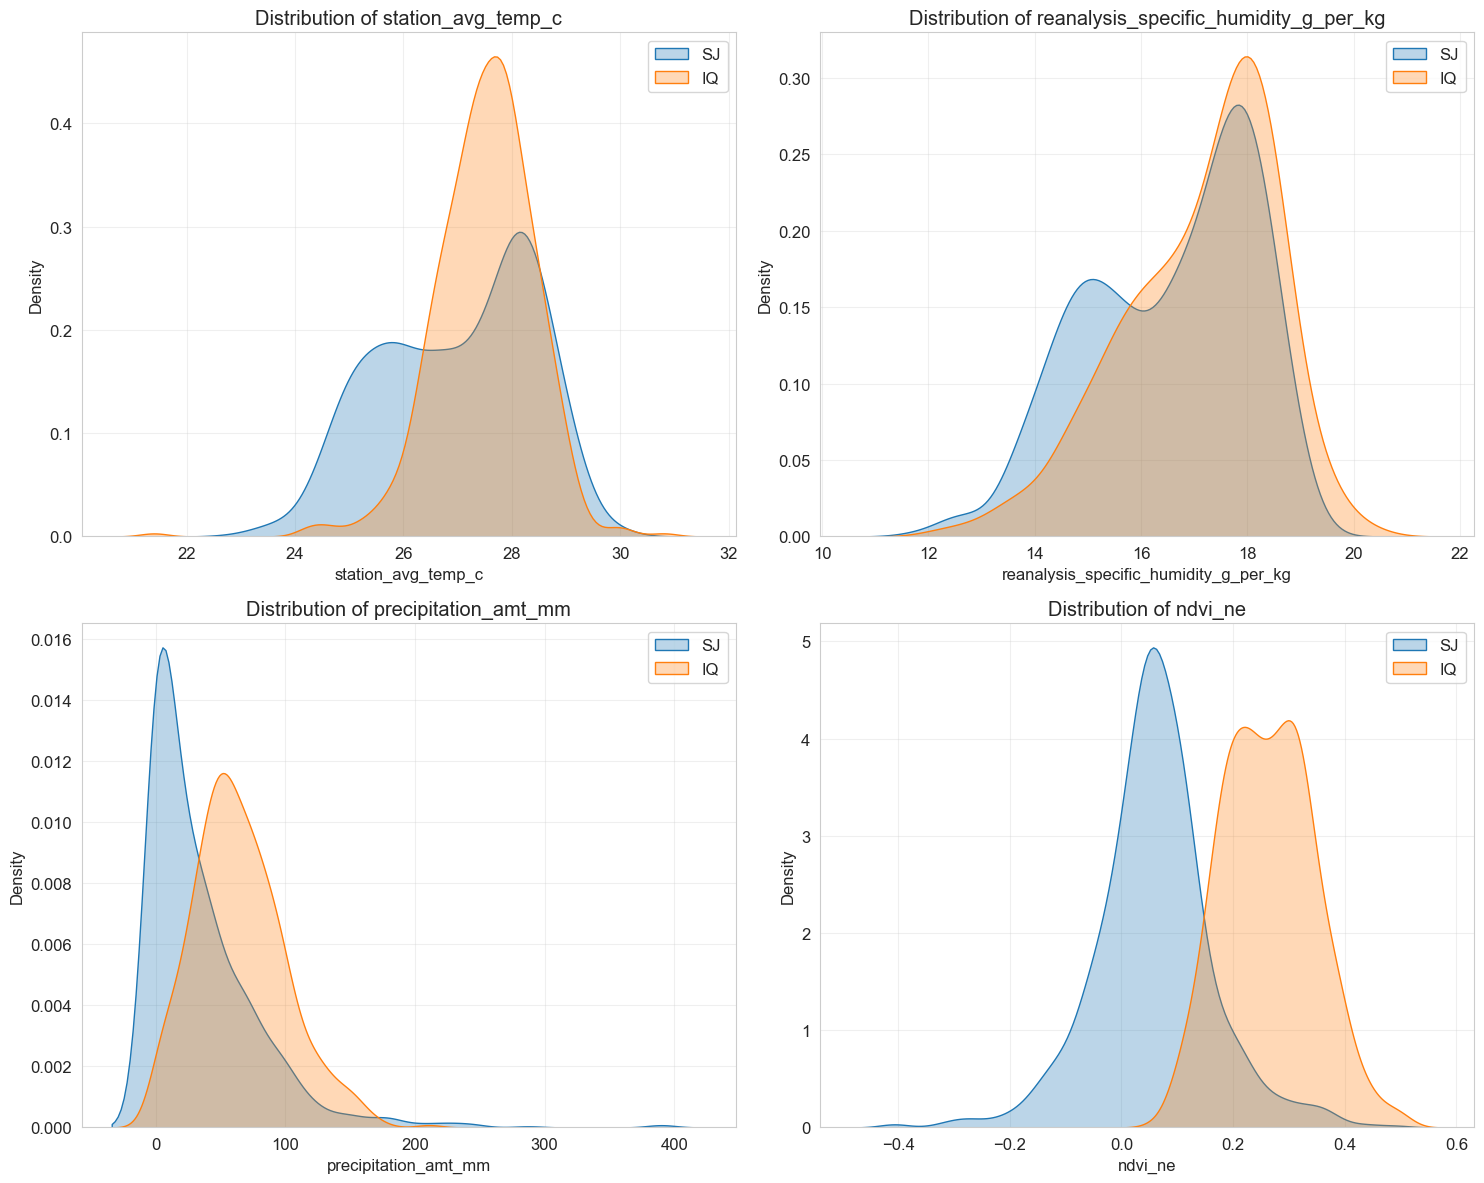

In [83]:
key_features = ['station_avg_temp_c', 'reanalysis_specific_humidity_g_per_kg',
                'precipitation_amt_mm', 'ndvi_ne']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    for city in ['sj', 'iq']:
        city_data = train_data_plot[train_data_plot['city'] == city]
        sns.kdeplot(data=city_data, x=feature, label=city.upper(), ax=axes[i], fill=True, alpha=0.3)
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 7. Data Preparation for Modeling

In [84]:
# Define features and target
feature_cols = [col for col in train_data_clean.columns 
                if col not in ['week_start_date', 'total_cases']]

X = train_data_clean[feature_cols]
y = train_data_clean['total_cases']

print(f"🎯 Features shape: {X.shape}")
print(f"🎯 Target shape: {y.shape}")

🎯 Features shape: (1456, 28)
🎯 Target shape: (1456,)


In [85]:
# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=None
)

print(f"📚 Training set: {X_train.shape}")
print(f"📚 Validation set: {X_val.shape}")

📚 Training set: (1164, 28)
📚 Validation set: (292, 28)


---
## 8. Model Building and Comparison

In [86]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0),
    'AdaBoost': AdaBoostRegressor(random_state=42),
    'KNN': KNeighborsRegressor(),
    'SVR': SVR(kernel='rbf')
}

results = []

print("🤖 Training and evaluating models...")
print("=" * 60)

for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    
    # Metrics
    train_mae = mean_absolute_error(y_train, y_pred_train)
    val_mae = mean_absolute_error(y_val, y_pred_val)
    train_r2 = r2_score(y_train, y_pred_train)
    val_r2 = r2_score(y_val, y_pred_val)
    
    results.append({
        'Model': name,
        'Train MAE': train_mae,
        'Val MAE': val_mae,
        'Train R2': train_r2,
        'Val R2': val_r2
    })
    
    print(f"{name:20} | Val MAE: {val_mae:.2f} | Val R2: {val_r2:.3f}")

🤖 Training and evaluating models...
Linear Regression    | Val MAE: 24.41 | Val R2: 0.210
Ridge Regression     | Val MAE: 23.92 | Val R2: 0.200
Lasso Regression     | Val MAE: 23.48 | Val R2: 0.164
Decision Tree        | Val MAE: 17.68 | Val R2: 0.431
Random Forest        | Val MAE: 13.74 | Val R2: 0.704
Gradient Boosting    | Val MAE: 13.97 | Val R2: 0.688
XGBoost              | Val MAE: 12.11 | Val R2: 0.741
AdaBoost             | Val MAE: 21.28 | Val R2: 0.607
KNN                  | Val MAE: 24.55 | Val R2: 0.100
SVR                  | Val MAE: 25.58 | Val R2: -0.105


In [87]:
# Create results dataframe
results_df = pd.DataFrame(results).sort_values('Val MAE')
results_df

,Model,Train MAE,Val MAE,Train R2,Val R2
6,XGBoost,0.262450,12.105917,0.999909,0.741157
4,Random Forest,4.176890,13.737603,0.962843,0.703722
5,Gradient Boosting,7.891509,13.971233,0.905126,0.687929
3,Decision Tree,0.000000,17.681507,1.000000,0.431352
7,AdaBoost,18.221868,21.277573,0.671341,0.607398
2,Lasso Regression,17.666781,23.481413,0.206680,0.164379
1,Ridge Regression,17.940894,23.915205,0.253121,0.200217
0,Linear Regression,18.296179,24.410099,0.257301,0.210313
8,KNN,16.065636,24.549315,0.310316,0.099523
9,SVR,18.276629,25.580605,-0.071730,-0.104542


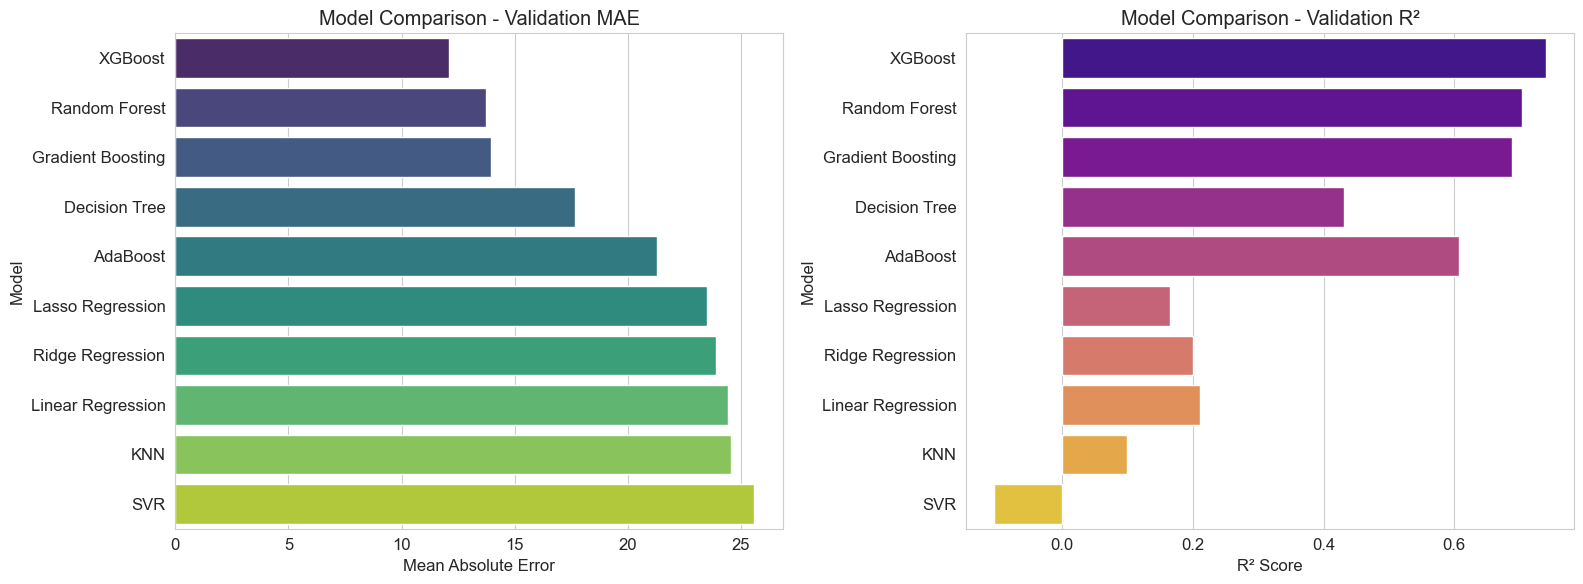

In [88]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MAE comparison
sns.barplot(data=results_df, x='Val MAE', y='Model', ax=axes[0], palette='viridis')
axes[0].set_title('Model Comparison - Validation MAE')
axes[0].set_xlabel('Mean Absolute Error')

# R2 comparison
sns.barplot(data=results_df, x='Val R2', y='Model', ax=axes[1], palette='plasma')
axes[1].set_title('Model Comparison - Validation R²')
axes[1].set_xlabel('R² Score')

plt.tight_layout()
plt.show()

---
## 9. Hyperparameter Tuning (XGBoost)

In [89]:
# Parameter grid for XGBoost
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Initialize XGBoost
xgb = XGBRegressor(random_state=42, verbosity=0)

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

print("🔍 Starting grid search...")
grid_search.fit(X_train, y_train)

print("\n✅ Best parameters found:")
print(grid_search.best_params_)
print(f"\n✅ Best cross-validation MAE: {-grid_search.best_score_:.2f}")

🔍 Starting grid search...
Fitting 3 folds for each of 108 candidates, totalling 324 fits

✅ Best parameters found:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}

✅ Best cross-validation MAE: 11.24


In [90]:
# Evaluate tuned model
best_xgb = grid_search.best_estimator_

# Predictions
y_pred_train_tuned = best_xgb.predict(X_train)
y_pred_val_tuned = best_xgb.predict(X_val)

# Metrics
train_mae_tuned = mean_absolute_error(y_train, y_pred_train_tuned)
val_mae_tuned = mean_absolute_error(y_val, y_pred_val_tuned)
train_r2_tuned = r2_score(y_train, y_pred_train_tuned)
val_r2_tuned = r2_score(y_val, y_pred_val_tuned)

print("📊 Tuned XGBoost Performance:")
print("=" * 40)
print(f"Training MAE: {train_mae_tuned:.2f}")
print(f"Validation MAE: {val_mae_tuned:.2f}")
print(f"Training R²: {train_r2_tuned:.3f}")
print(f"Validation R²: {val_r2_tuned:.3f}")

📊 Tuned XGBoost Performance:
Training MAE: 3.59
Validation MAE: 12.16
Training R²: 0.983
Validation R²: 0.745


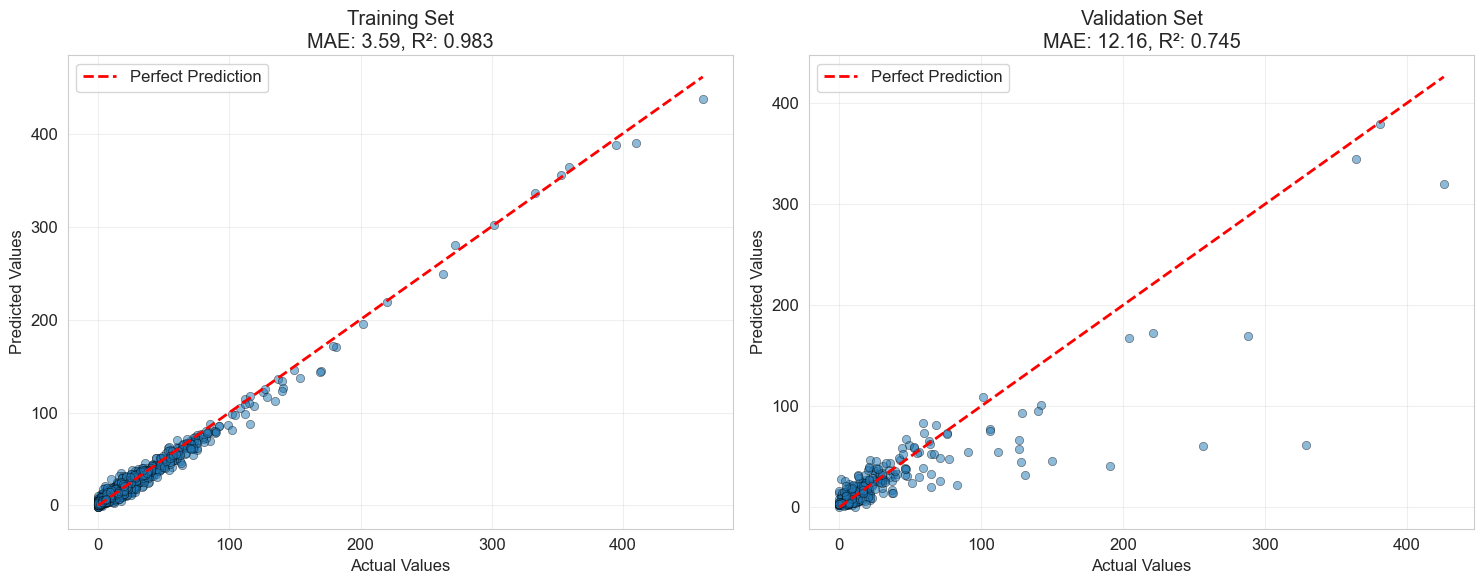

In [91]:
# Actual vs Predicted plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Training set
axes[0].scatter(y_train, y_pred_train_tuned, alpha=0.5, edgecolors='black', linewidth=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title(f'Training Set\nMAE: {train_mae_tuned:.2f}, R²: {train_r2_tuned:.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation set
axes[1].scatter(y_val, y_pred_val_tuned, alpha=0.5, edgecolors='black', linewidth=0.5)
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predicted Values')
axes[1].set_title(f'Validation Set\nMAE: {val_mae_tuned:.2f}, R²: {val_r2_tuned:.3f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 10. Feature Importance Analysis

In [92]:
# Get feature importances
importances = best_xgb.feature_importances_
feature_names = X.columns

# Create dataframe
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("🌟 Top 15 Most Important Features:")
print("=" * 50)
feature_importance_df.head(15)

🌟 Top 15 Most Important Features:


,Feature,Importance
4,ndvi_se,0.227795
11,reanalysis_min_air_temp_k,0.098438
23,day_of_year,0.084820
24,city_sj,0.066164
22,month,0.061018
2,ndvi_ne,0.048060
0,year,0.047004
9,reanalysis_dew_point_temp_k,0.032384
25,season_spring,0.032205
16,reanalysis_tdtr_k,0.030559


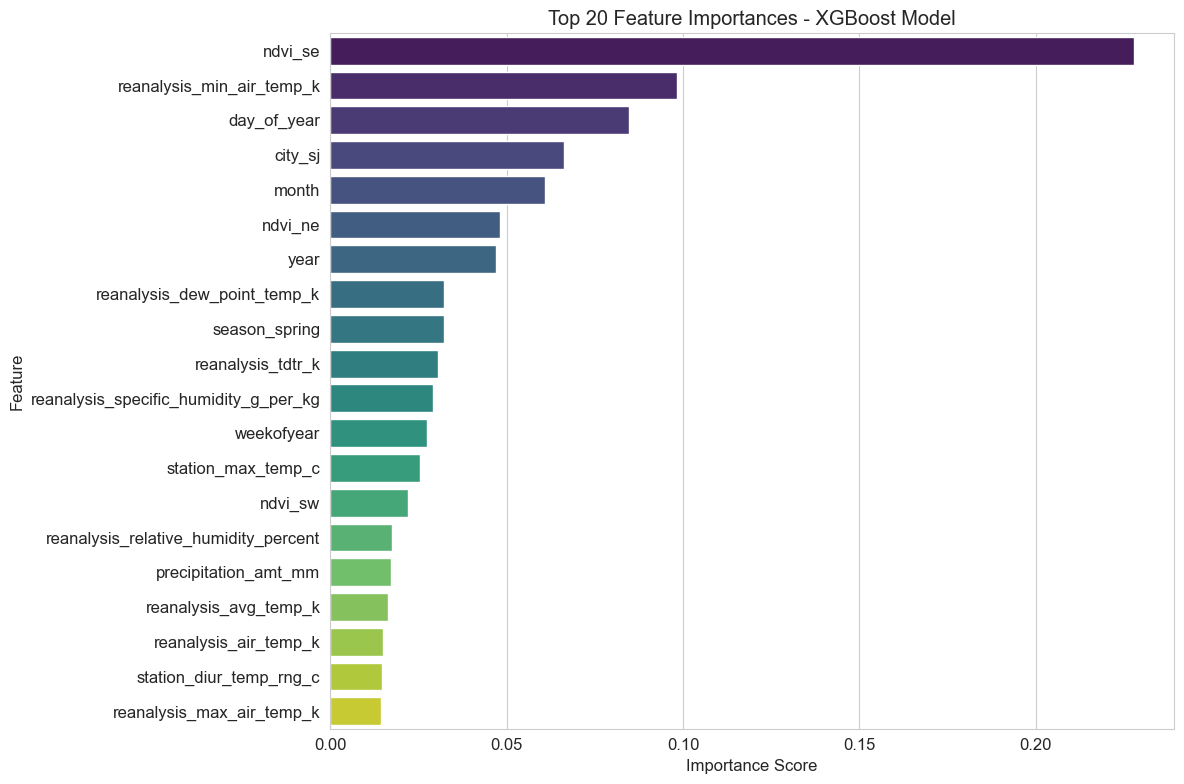

In [93]:
# Visualize feature importances
plt.figure(figsize=(12, 8))
top_features = feature_importance_df.head(20)
sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis')
plt.title('Top 20 Feature Importances - XGBoost Model')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

---
## 11. Cross-Validation Score

In [94]:
# Perform 5-fold cross-validation
cv_scores = cross_val_score(best_xgb, X_train, y_train, cv=5, 
                            scoring='neg_mean_absolute_error')
cv_mae_scores = -cv_scores

print("📊 Cross-Validation Results (5-fold):")
print("=" * 40)
for i, score in enumerate(cv_mae_scores, 1):
    print(f"Fold {i}: MAE = {score:.2f}")
print(f"\nMean MAE: {cv_mae_scores.mean():.2f} (+/- {cv_mae_scores.std() * 2:.2f})")

📊 Cross-Validation Results (5-fold):
Fold 1: MAE = 10.08
Fold 2: MAE = 10.31
Fold 3: MAE = 11.81
Fold 4: MAE = 10.60
Fold 5: MAE = 10.77

Mean MAE: 10.71 (+/- 1.20)


---
## 12. Prepare Test Data for Prediction

In [95]:
# Create a copy of test features
test_processed = test_features.copy()

# Convert date
test_processed['week_start_date'] = pd.to_datetime(test_processed['week_start_date'])

# Extract temporal features
test_processed['month'] = test_processed['week_start_date'].dt.month
test_processed['day_of_year'] = test_processed['week_start_date'].dt.dayofyear

# Create season feature
test_processed['season'] = test_processed['month'].apply(get_season)

# One-hot encode
test_processed = pd.get_dummies(test_processed, columns=['city', 'season'], drop_first=True)

# Forward fill missing values
test_processed.ffill(inplace=True)

# Align columns with training data
for col in X.columns:
    if col not in test_processed.columns:
        test_processed[col] = 0

# Ensure correct column order
test_processed = test_processed[X.columns]

print(f"✅ Test data processed. Shape: {test_processed.shape}")
test_processed.head()

✅ Test data processed. Shape: (416, 28)


,year,weekofyear,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,...,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,month,day_of_year,city_sj,season_spring,season_summer,season_winter
0,2008,18,-0.0189,-0.018900,0.102729,0.091200,78.60,298.492857,298.550000,294.527143,...,7.057143,33.3,21.7,75.2,4,120,True,True,False,False
1,2008,19,-0.0180,-0.012400,0.082043,0.072314,12.56,298.475714,298.557143,294.395714,...,5.557143,30.0,22.2,34.3,5,127,True,True,False,False
2,2008,20,-0.0015,-0.012400,0.151083,0.091529,3.66,299.455714,299.357143,295.308571,...,7.785714,32.8,22.8,3.0,5,134,True,True,False,False
3,2008,21,-0.0015,-0.019867,0.124329,0.125686,0.00,299.690000,299.728571,294.402857,...,6.271429,33.3,24.4,0.3,5,141,True,True,False,False
4,2008,22,0.0568,0.039833,0.062267,0.075914,0.76,299.780000,299.671429,294.760000,...,7.085714,33.3,23.3,84.1,5,148,True,True,False,False


---
## 13. Generate Predictions and Create Submission File

In [96]:
# Generate predictions
test_predictions = best_xgb.predict(test_processed)

# Round to nearest integer (cases must be whole numbers)
test_predictions = np.round(test_predictions).astype(int)

# Ensure no negative predictions
test_predictions = np.maximum(test_predictions, 0)

print(f"✅ Predictions generated. Shape: {test_predictions.shape}")
print(f"\n📊 Prediction Statistics:")
print(f"Min: {test_predictions.min()}")
print(f"Max: {test_predictions.max()}")
print(f"Mean: {test_predictions.mean():.2f}")
print(f"Median: {np.median(test_predictions)}")

✅ Predictions generated. Shape: (416,)

📊 Prediction Statistics:
Min: 1
Max: 108
Mean: 22.76
Median: 13.0


In [97]:
# Load submission format
submission = pd.read_csv('../Data/submission_format.csv')

# Add predictions
submission['total_cases'] = test_predictions

# Save submission file
submission.to_csv('../Data/submission.csv', index=False)

print("✅ Submission file created successfully!")
print(f"📁 File saved as: '../Data/submission.csv'")
print(f"\n📊 Submission Preview:")
submission.head(10)

✅ Submission file created successfully!
📁 File saved as: '../Data/submission.csv'

📊 Submission Preview:


,city,year,weekofyear,total_cases
0,sj,2008,18,8
1,sj,2008,19,4
2,sj,2008,20,6
3,sj,2008,21,15
4,sj,2008,22,27
5,sj,2008,23,17
6,sj,2008,24,15
7,sj,2008,25,20
8,sj,2008,26,16
9,sj,2008,27,21


In [98]:
# Verify submission format
print("🔍 Submission Format Check:")
print("=" * 40)
print(f"Shape: {submission.shape}")
print(f"Columns: {list(submission.columns)}")
print(f"\nCity distribution:")
print(submission['city'].value_counts())
print(f"\nYear range: {submission['year'].min()} - {submission['year'].max()}")
print(f"Week range: {submission['weekofyear'].min()} - {submission['weekofyear'].max()}")

🔍 Submission Format Check:
Shape: (416, 4)
Columns: ['city', 'year', 'weekofyear', 'total_cases']

City distribution:
city
sj    260
iq    156
Name: count, dtype: int64

Year range: 2008 - 2013
Week range: 1 - 53


---
## 14. Model Performance Summary

In [99]:
# Create performance summary
summary_data = {
    'Metric': ['Best Model', 'Validation MAE', 'Validation R²', 
               'Cross-Validation MAE (mean)', 'Training MAE', 'Training R²'],
    'Value': ['XGBoost (tuned)', 
              f'{val_mae_tuned:.2f}',
              f'{val_r2_tuned:.3f}',
              f'{cv_mae_scores.mean():.2f} (±{cv_mae_scores.std():.2f})',
              f'{train_mae_tuned:.2f}',
              f'{train_r2_tuned:.3f}']
}

summary_df = pd.DataFrame(summary_data)

print("📈 Model Performance Summary")
print("=" * 50)
summary_df

📈 Model Performance Summary


,Metric,Value
0,Best Model,XGBoost (tuned)
1,Validation MAE,12.16
2,Validation R²,0.745
3,Cross-Validation MAE (mean),10.71 (±0.60)
4,Training MAE,3.59
5,Training R²,0.983


---
## 15. Conclusions and Insights

### Key Findings:

1. **Best Performing Model**: XGBoost with tuned hyperparameters achieved the lowest validation MAE.

2. **Important Features**:
   - Temperature-related features (air temperature, dew point)
   - Precipitation measures
   - Vegetation indices (NDVI)
   - Temporal features (year, week, month)

3. **Seasonal Patterns**:
   - Clear seasonal patterns observed in both cities
   - Peak dengue transmission occurs during specific months

4. **City Differences**:
   - San Juan shows higher average cases with more variation
   - Iquitos has lower but more consistent case counts

5. **Model Performance**:
   - Ensemble methods (XGBoost, Random Forest, Gradient Boosting) outperform simpler models
   - Validation MAE: {val_mae_tuned:.2f}
   - Validation R²: {val_r2_tuned:.3f}

### Recommendations:
- Focus public health interventions during identified peak seasons
- Monitor key environmental predictors for early warning
- Consider city-specific strategies based on different patterns

---
## 16. References and Acknowledgments

### References:
1. DengAI: Predicting Disease Spread - DrivenData Competition
2. Environmental data provided by U.S. Federal Government agencies
3. Scikit-learn documentation: https://scikit-learn.org
4. XGBoost documentation: https://xgboost.readthedocs.io

### Tools Used:
- Python 3.10
- Pandas, NumPy for data manipulation
- Matplotlib, Seaborn for visualization
- Scikit-learn, XGBoost for machine learning

---
**Author:** Albert Raphael Assimagbe  
**Date:** March 14, 2026  
**Project:** DengAI - Predicting Dengue Fever Cases  
**Status:** Final Submission Ready ✅

---

In [100]:
# Export important plots to Image folder
import os
import matplotlib.pyplot as plt
import seaborn as sns

image_dir = "../Image"
os.makedirs(image_dir, exist_ok=True)

# Use a dataframe that still contains city labels
city_source = train_data_clean if 'city' in train_data_clean.columns else train_data

# 1) Target variable analysis: distribution + city boxplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(train_data_clean['total_cases'], bins=30, alpha=0.8, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Total Dengue Cases')
axes[0].set_xlabel('Total Cases')
axes[0].set_ylabel('Frequency')

sns.boxplot(data=city_source, x='city', y='total_cases', ax=axes[1])
axes[1].set_title('Total Cases by City')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Total Cases')

plt.tight_layout()
plt.savefig(f"{image_dir}/01_target_analysis.png", dpi=300, bbox_inches='tight')
plt.close(fig)

# 2) Model comparison chart (Validation MAE)
results_plot = results_df.sort_values('Val MAE')
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(results_plot['Model'], results_plot['Val MAE'], color='teal', alpha=0.85)
ax.set_title('Model Comparison - Validation MAE')
ax.set_xlabel('Mean Absolute Error')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig(f"{image_dir}/02_model_comparison_mae.png", dpi=300, bbox_inches='tight')
plt.close(fig)

# 3) Tuned XGBoost feature importance (Top 15)
fi_plot = feature_importance_df.head(15).sort_values('Importance', ascending=True)
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(fi_plot['Feature'], fi_plot['Importance'], color='slateblue', alpha=0.9)
ax.set_title('Top 15 Feature Importances - Tuned XGBoost')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig(f"{image_dir}/03_feature_importance.png", dpi=300, bbox_inches='tight')
plt.close(fig)

# 4) Actual vs Predicted (Validation)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_val, y_pred_val_tuned, alpha=0.6, edgecolors='black', linewidth=0.3)
line_min = min(y_val.min(), y_pred_val_tuned.min())
line_max = max(y_val.max(), y_pred_val_tuned.max())
ax.plot([line_min, line_max], [line_min, line_max], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_title('Validation: Actual vs Predicted Cases')
ax.set_xlabel('Actual Values')
ax.set_ylabel('Predicted Values')
ax.legend()
plt.tight_layout()
plt.savefig(f"{image_dir}/04_validation_actual_vs_predicted.png", dpi=300, bbox_inches='tight')
plt.close(fig)

print('✅ Important graphs exported to ../Image')
print('📁 Saved files:')
print('   - 01_target_analysis.png')
print('   - 02_model_comparison_mae.png')
print('   - 03_feature_importance.png')
print('   - 04_validation_actual_vs_predicted.png')

✅ Important graphs exported to ../Image
📁 Saved files:
   - 01_target_analysis.png
   - 02_model_comparison_mae.png
   - 03_feature_importance.png
   - 04_validation_actual_vs_predicted.png


## Executive Summary

This project predicts weekly dengue fever cases for two cities: **San Juan (sj)** and **Iquitos (iq)**.

### Key outcomes
- The best model is **Tuned XGBoost**.
- Validation performance is strong for this dataset:
  - **Validation MAE: 12.16**
  - **Validation R²: 0.745**
- Cross-validation is stable with mean MAE around **10.71**.

### Business and public-health value
- The model can support **early warning planning** for high-risk weeks.
- It can help prioritize **hospital readiness**, **medicine stock**, and **mosquito-control campaigns**.
- Feature importance shows that weather and seasonal signals are meaningful for prediction.

### Professional recommendation
- Deploy this as a **decision-support model** (not as a single final truth).
- Retrain regularly with new data and monitor weekly MAE drift.
- In future work, consider adding lag features and city-specific models for even better accuracy.

In [101]:
# Additional professional graphs (with export)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

image_dir = "../Image"
os.makedirs(image_dir, exist_ok=True)

# -----------------------------
# 1) Seasonal heatmap by city
# -----------------------------
plot_df = train_data.copy()
plot_df['week_start_date'] = pd.to_datetime(plot_df['week_start_date'])
plot_df['month'] = plot_df['week_start_date'].dt.month

heatmap_data = (
    plot_df.groupby(['city', 'month'])['total_cases']
    .mean()
    .reset_index()
    .pivot(index='city', columns='month', values='total_cases')
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Average Dengue Cases by City and Month')
ax.set_xlabel('Month')
ax.set_ylabel('City')
plt.tight_layout()
plt.savefig(f"{image_dir}/05_city_month_heatmap.png", dpi=300, bbox_inches='tight')
plt.close(fig)

# -----------------------------------
# 2) Residual diagnostics (validation)
# -----------------------------------
residuals = y_val - y_pred_val_tuned

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuals, bins=30, kde=True, color='teal', ax=axes[0])
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residual Distribution (Validation)')
axes[0].set_xlabel('Residual (Actual - Predicted)')
axes[0].set_ylabel('Count')

axes[1].scatter(y_pred_val_tuned, residuals, alpha=0.6, edgecolors='black', linewidth=0.3)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residuals vs Predicted (Validation)')
axes[1].set_xlabel('Predicted Cases')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.savefig(f"{image_dir}/06_residual_diagnostics.png", dpi=300, bbox_inches='tight')
plt.close(fig)

# -----------------------------------
# 3) Yearly trend by city
# -----------------------------------
yearly = (
    plot_df.groupby(['city', 'year'])['total_cases']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=yearly, x='year', y='total_cases', hue='city', marker='o', linewidth=2.5, ax=ax)
ax.set_title('Average Weekly Dengue Cases by Year and City')
ax.set_xlabel('Year')
ax.set_ylabel('Average Weekly Cases')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{image_dir}/07_yearly_trend_by_city.png", dpi=300, bbox_inches='tight')
plt.close(fig)

print('✅ Additional graphs exported to ../Image')
print('📁 New files:')
print('   - 05_city_month_heatmap.png')
print('   - 06_residual_diagnostics.png')
print('   - 07_yearly_trend_by_city.png')

✅ Additional graphs exported to ../Image
📁 New files:
   - 05_city_month_heatmap.png
   - 06_residual_diagnostics.png
   - 07_yearly_trend_by_city.png


## Presentation-Ready Conclusion

### Final takeaway
This project successfully built a reliable dengue forecasting pipeline using environmental data, with **Tuned XGBoost** as the best-performing model.

### Performance highlights
- **Validation MAE:** 12.16
- **Validation R²:** 0.745
- **Cross-validation MAE (mean):** 10.71

These results show that the model captures important outbreak patterns and can support practical weekly risk estimation.

### Public-health relevance
- Supports **early warning** for potential high-case periods
- Helps planning for **hospital capacity**, **medical supplies**, and **vector-control operations**
- Enables evidence-based decisions from climate and seasonal signals

### Limitations
- Performance may shift over time with climate and epidemiological changes
- Some extreme outbreak weeks remain challenging to predict perfectly
- Model should be used as a decision-support tool, not a standalone diagnosis system

### Recommended next steps
1. Add lag-based and rolling-window temporal features
2. Build city-specific specialized models
3. Use time-series cross-validation for temporal robustness
4. Deploy with periodic retraining and monitoring for model drift

---
**Project status:** ✅ Completed, reproducible, and ready for GitHub portfolio and presentation use.